In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
data=pd.read_csv(r"C:/Users/SHIVAM/Downloads/Sample - Superstore.csv",encoding='latin1')

In [12]:
data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# converting date columns

In [13]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [14]:
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [59]:
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year
data['Order Day of week'] = data['Order Date'].dt.dayofweek


In [60]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day of week,Order_Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,1,Nov
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,1,Nov
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,6,Jun
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,6,Oct
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,6,Oct


# Mothly sales analysis

In [51]:
sales_by_month = data.groupby('Order Month')['Sales'].sum().reset_index()

In [52]:
sales_by_month


,Order Month,Sales
0,Apr,137762.1286
1,Aug,159044.0630
2,Dec,325293.5035
3,Feb,59751.2514
4,Jan,94924.8356
5,Jul,147238.0970
6,Jun,152718.6793
7,Mar,205005.4888
8,May,155028.8117
9,Nov,352461.0710


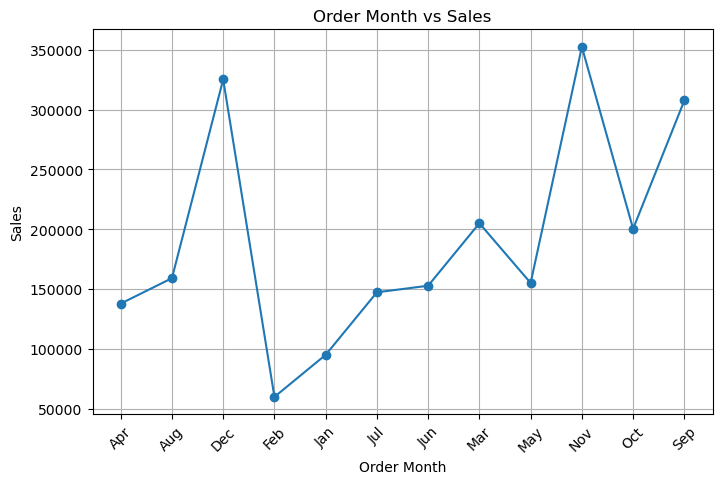

In [74]:
plt.figure(figsize=(8,5))

plt.plot(sales_by_month['Order Month'], 
         sales_by_month['Sales'], 
         marker='o')

plt.xticks(rotation=45)
plt.xlabel('Order Month')
plt.ylabel('Sales')
plt.title('Order Month vs Sales')
plt.grid()
plt.show()

# sales bt category

In [70]:
sales_by_cat=data.groupby('Category')['Sales'].sum().reset_index()

In [71]:
sales_by_cat

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


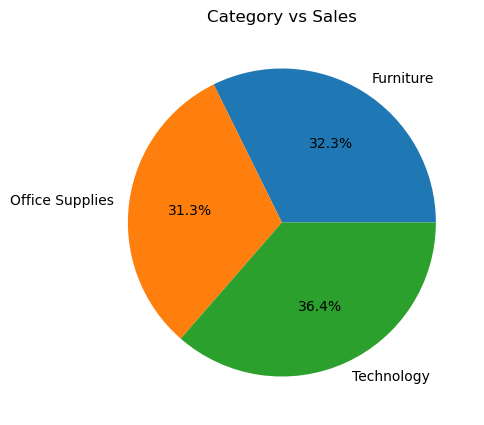

In [73]:
plt.figure(figsize=(5,5))

plt.pie(sales_by_cat['Sales'], 
        labels=sales_by_cat['Category'], 
        autopct='%1.1f%%')

plt.title('Category vs Sales')

plt.show()

# sales_by_subcat

In [75]:
sales_by_subcat=data.groupby('Sub-Category')['Sales'].sum().reset_index()

In [77]:
sales_by_subcat = sales_by_subcat.sort_values('Sales', ascending=False)

In [78]:
sales_by_subcat

,Sub-Category,Sales
13,Phones,330007.0540
5,Chairs,328449.1030
14,Storage,223843.6080
16,Tables,206965.5320
3,Binders,203412.7330
11,Machines,189238.6310
0,Accessories,167380.3180
6,Copiers,149528.0300
4,Bookcases,114879.9963
1,Appliances,107532.1610


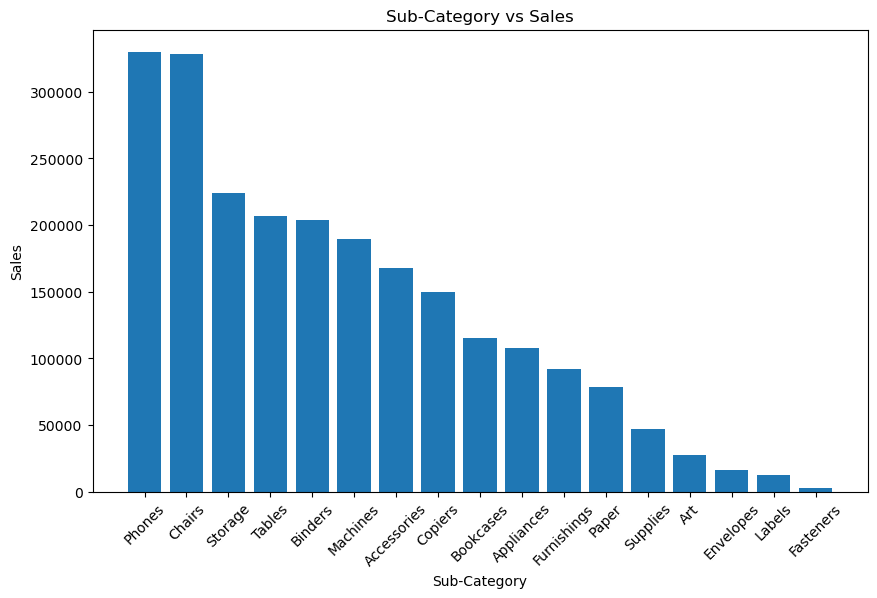

In [80]:
plt.figure(figsize=(10,6))

plt.bar(sales_by_subcat['Sub-Category'], 
        sales_by_subcat['Sales'])

plt.xticks(rotation=45)
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.title('Sub-Category vs Sales')

plt.show()

# profit_by_month

In [81]:
profit_by_month=data.groupby('Order Month')['Profit'].sum().reset_index()

In [82]:
profit_by_month

,Order Month,Profit
0,1,9134.4461
1,2,10294.6107
2,3,28594.6872
3,4,11587.4363
4,5,22411.3078
5,6,21285.7954
6,7,13832.6648
7,8,21776.9384
8,9,36857.4753
9,10,31784.0413


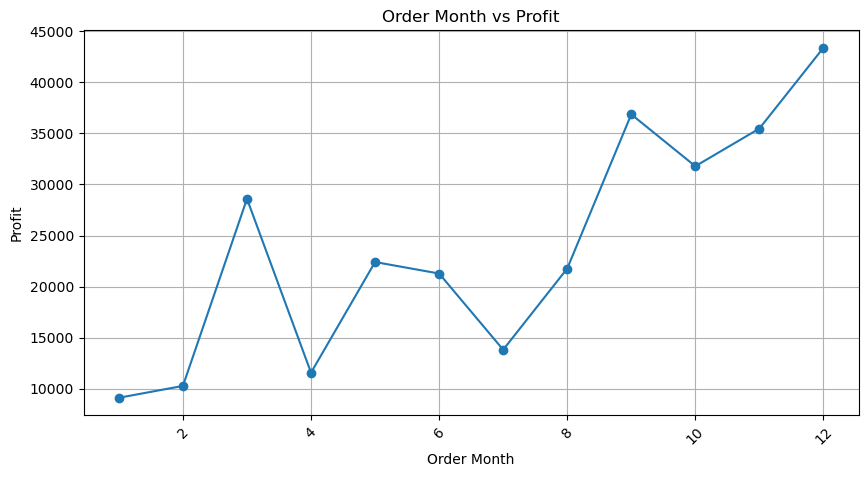

In [83]:
plt.figure(figsize=(10,5))

plt.plot(profit_by_month['Order Month'], 
         profit_by_month['Profit'], 
         marker='o')

plt.xticks(rotation=45)
plt.xlabel('Order Month')
plt.ylabel('Profit')
plt.title('Order Month vs Profit')

plt.grid()

# profit_by_cat

In [84]:
profit_by_cat=data.groupby('Category')['Profit'].sum().reset_index()

In [85]:
profit_by_cat

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


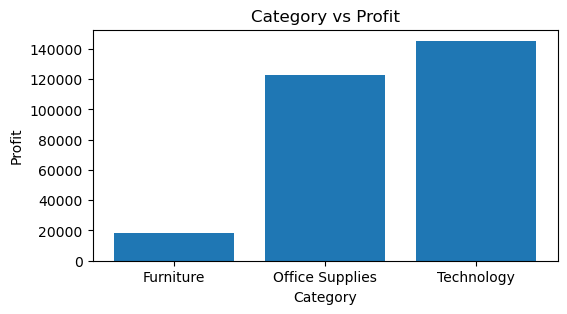

In [87]:
plt.figure(figsize=(6,3))

plt.bar(profit_by_cat['Category'], 
        profit_by_cat['Profit'])

plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Category vs Profit')

plt.show()